In [1]:
import parcels
import numpy as np
from datetime import timedelta
from glob import glob
import matplotlib.pyplot as plt
import xarray as xr
import os
from parcels.tools.loggers import logger

def u2rho_2d (var_u):
    [Mp,L]=var_u.shape
    Lp=L+1
    Lm=L-1
    var_rho=np.zeros((Mp,Lp))
    var_rho[:,1:-1]=0.5*(var_u[:,1:]+var_u[:,:-1])
    var_rho[:,0]=var_rho[:,1]
    var_rho[:,-1]=var_rho[:,-2]
    return var_rho
    
def v2rho_2d (var_v):
    [M,Lp]=var_v.shape
    Mp=M+1
    Mm=M-1
    var_rho=np.zeros((Mp,Lp))
    var_rho[1:-1,:]=0.5*(var_v[1:,:]+var_v[:-1,:])
    var_rho[0,:]=var_rho[1,:]
    var_rho[-1,:]=var_rho[-2,:]
    return var_rho

def u2rho_3d (var_u):
    [N,Mp,L]=var_u.shape
    Lp=L+1
    Lm=L-1
    var_rho=np.zeros((N,Mp,Lp))
    var_rho[:,:,1:-1]=0.5*(var_u[:,:,1:]+var_u[:,:,:-1])
    var_rho[:,:,0]=var_rho[:,:,1]
    var_rho[:,:,-1]=var_rho[:,:,-2]
    return var_rho
    
def v2rho_3d (var_v):
    [N,M,Lp]=var_v.shape
    Mp=M+1
    Mm=M-1
    var_rho=np.zeros((N,Mp,Lp))
    var_rho[:,1:-1,:]=0.5*(var_v[:,1:,:]+var_v[:,:-1,:])
    var_rho[:,0,:]=var_rho[:,1,:]
    var_rho[:,-1,:]=var_rho[:,-2,:]
    return var_rho

def spheric_dist(lat1, lat2, lon1, lon2):
    """
    Compute the spherical distance between two points on Earth.
    
    Parameters:
    lat1, lat2 : array-like
        Latitude of the two points (in degrees).
    lon1, lon2 : array-like
        Longitude of the two points (in degrees).
    
    Returns:
    dist : array-like
        The spherical distance between the points (in meters).
    """
    
    # Earth radius in meters
    R = 6367442.76
    
    # Determine proper longitudinal shift
    l = np.abs(lon2 - lon1)
    l[l >= 180] = 360 - l[l >= 180]
    
    # Convert decimal degrees to radians
    deg2rad = np.pi / 180
    lat1 = lat1 * deg2rad
    lat2 = lat2 * deg2rad
    l = l * deg2rad
    
    # Compute the distances
    dist = R * np.arcsin(np.sqrt(((np.sin(l) * np.cos(lat2)) ** 2) + 
                                 ((np.sin(lat2) * np.cos(lat1)) - 
                                  (np.sin(lat1) * np.cos(lat2) * np.cos(l))) ** 2))
    
    return dist

def spheric_dist_one(lat1, lat2, lon1, lon2):
    """计算两个经纬度点之间的球面距离（标量版）"""
    # 处理经度差
    l = np.abs(lon2 - lon1)
    if l >= 180:
        l = 360 - l
    
    # 转换为弧度
    deg2rad = np.pi / 180
    lat1_rad = lat1 * deg2rad
    lat2_rad = lat2 * deg2rad
    l_rad = l * deg2rad
    
    # 球面距离公式
    distance = 6371 * np.arccos(
        np.sin(lat1_rad) * np.sin(lat2_rad) + 
        np.cos(lat1_rad) * np.cos(lat2_rad) * np.cos(l_rad)
    )
    return distance

from scipy.spatial import cKDTree
def find_nearest_grid_index(lon_rho, lat_rho, lon_points, lat_points):
    """
    为每个经纬度点找到最近的网格点索引
    
    参数:
    lon_rho: 2D网格经度数组 (shape: [ny, nx])
    lat_rho: 2D网格纬度数组 (shape: [ny, nx])
    lon_points: 1D经度点数组 (shape: [ntime])
    lat_points: 1D纬度点数组 (shape: [ntime])
    
    返回:
    i_indices: 最近网格点的y轴索引数组 (shape: [ntime])
    j_indices: 最近网格点的x轴索引数组 (shape: [ntime])
    distances: 到最近网格点的距离数组 (km, shape: [ntime])
    """
    # 1. 创建网格点的坐标数组
    grid_points = np.column_stack((lon_rho.ravel(), lat_rho.ravel()))
    
    # 2. 创建查询点的坐标数组
    query_points = np.column_stack((lon_points, lat_points))
    
    # 3. 构建KDTree进行最近邻搜索
    tree = cKDTree(grid_points)
    
    # 4. 查询最近邻
    distances, indices = tree.query(query_points, k=1)
    
    # 5. 将一维索引转换为二维网格索引
    ny, nx = lon_rho.shape
    j_indices = indices % nx  # x轴索引
    i_indices = indices // nx  # y轴索引
    
    # 6. 将角度距离转换为公里
    # 使用球面距离公式：距离(km) = 角度距离(度) * 111.32
    distances_km = distances * 111.32
    
    return i_indices, j_indices, distances_km

def freqspec(u1,v1,fs=1.0,window=True):
    # fs Hz ~1/dt
    from scipy.fft import fft, fftfreq
    from scipy.signal import welch, periodogram
    N=len(u1)
    if window:
        window=np.hanning(N)
    else:
        window=np.ones((N))
    # print(window)
    yf1 = fft(u1*window)
    yf2 = fft(v1*window)
    xf = fftfreq(N, 1/fs)
    
    # 计算幅度谱
    magnitude = 0.5*(np.abs(yf1)+np.abs(yf2))
    XF=xf[:N//2], 
    SPEC=2.0/N * magnitude[:N//2]
    return XF[0],SPEC

def transunit_spher2flat(u,v,lat):
    v1=v*1852*60
    u1=u*1852*60*np.cos(lat*np.pi/180)
    return u1,v1

In [2]:
grid_dir='/meddy/simingzhang/Data/RB_iceland_data/'
wave_dir='/meddy/simingzhang/Data/Parcels_data/'
# nowave_dir='/meddy/simingzhang/Data/RB_iceland_data/iceland_no_wave/'
grdname='niskin2km_500m_grd.nc'
# hisname_w='z_niskin2km_his_hf_depth_500m_grd.0002.nc'
# hisname_nw='z_niskin2km_his_smooth_depth_500m_grd.0002.nc'

grdname=f'{grid_dir}{grdname}'
# wavename=f'{wave_dir}{hisname_w}'
# nowavename=f'{nowave_dir}{hisname_nw}'

wavename=f'{wave_dir}wavecase_modified_cg.nc'
nowavename=f'{wave_dir}nowavecase_modified_cg.nc'

In [3]:
grid=xr.open_dataset(grdname)
grid = grid.swap_dims({'eta_u': 'eta_rho','xi_v':'xi_rho'})

lon_rho=grid['lon_rho']
lat_rho=grid['lat_rho']
h=grid['h']
lonmin=np.min(lon_rho.values)
lonmax=np.max(lon_rho.values)
latmin=np.min(lat_rho.values)
latmax=np.max(lat_rho.values)
lonmin,lonmax,latmin,latmax
grid

<xarray.Dataset> Size: 19MB
Dimensions:    (one: 1, eta_rho: 287, xi_rho: 287, bath: 1, xi_u: 286,
                eta_v: 286, eta_psi: 286, xi_psi: 286)
Dimensions without coordinates: one, eta_rho, xi_rho, bath, xi_u, eta_v,
                                eta_psi, xi_psi
Data variables: (12/34)
    xl         (one) float64 8B ...
    el         (one) float64 8B ...
    depthmin   (one) float64 8B ...
    depthmax   (one) float64 8B ...
    spherical  (one) |S1 1B ...
    angle      (eta_rho, xi_rho) float64 659kB ...
    ...         ...
    lat_v      (eta_v, xi_rho) float64 657kB ...
    lat_psi    (eta_psi, xi_psi) float64 654kB ...
    mask_rho   (eta_rho, xi_rho) float64 659kB ...
    mask_u     (eta_rho, xi_u) float64 657kB ...
    mask_v     (eta_v, xi_rho) float64 657kB ...
    mask_psi   (eta_psi, xi_psi) float64 654kB ...
Attributes:
    title:    Solomon Model
    date:     08-Apr-2018
    type:     ROMS grid file

In [4]:
# ds = xr.open_dataset(f'{wave_dir}test10.nc')
# ds
# depth=ds['depth'].values

In [86]:
ds = xr.open_dataset(f'{wave_dir}test1.nc')

ds['lon_rho']=lon_rho
ds['lat_rho']=lat_rho

ds.squeeze(dim='depth')
ds

<xarray.Dataset> Size: 24MB
Dimensions:     (depth: 1, time: 10, eta_rho: 287, xi_u: 286, eta_v: 286,
                 xi_rho: 287)
Coordinates:
  * depth       (depth) float32 4B -2.0
    lon_rho     (eta_rho, xi_rho) float64 659kB -30.93 -30.89 ... -19.99 -19.95
    lat_rho     (eta_rho, xi_rho) float64 659kB 57.6 57.59 57.59 ... 61.39 61.38
Dimensions without coordinates: time, eta_rho, xi_u, eta_v, xi_rho
Data variables:
    ocean_time  (time) float32 40B ...
    u           (time, depth, eta_rho, xi_u) float32 3MB ...
    v           (time, depth, eta_v, xi_rho) float32 3MB ...
    w           (time, depth, eta_rho, xi_rho) float32 3MB ...
    u_rho       (time, depth, eta_rho, xi_rho) float64 7MB ...
    v_rho       (time, depth, eta_rho, xi_rho) float64 7MB ...
Attributes:
    history:                   Thu Aug 28 13:18:24 2025: ncea -d time,1,10 te...
    nco_openmp_thread_number:  1
    NCO:                       netCDF Operators version 5.2.6 (Homepage = htt...

# ones


In [6]:
u_rho = np.zeros(ds['w'].shape)
u_rho[:,0,:,:]=u2rho_3d(np.squeeze(ds['u'].values))
# u_rho[np.abs(u_rho)<1e-3]=np.nan
ds["u_rho"] = (("time", "depth", "eta_rho", "xi_rho"), -2.5*np.ones((10,1,287,287)))
v_rho = np.zeros(ds['w'].shape)
v_rho[:,0,:,:]=v2rho_3d(np.squeeze(ds['v'].values))
# v_rho[np.abs(v_rho)<1e-3]=np.nan
ds["v_rho"] = (("time", "depth", "eta_rho", "xi_rho"), 8*np.ones((10,1,287,287)))

In [7]:
# ds['depth']=1
ds = ds.assign_coords(depth=[-5])


In [101]:
ds['depth']

<xarray.DataArray 'depth' (depth: 1)> Size: 8B
array([-5])
Coordinates:
  * depth    (depth) int64 8B -5

In [102]:
ds.to_netcdf(f'{wave_dir}testones10.nc')
# del ds

In [8]:
ur=ds['u_rho']
vr=ds['v_rho']

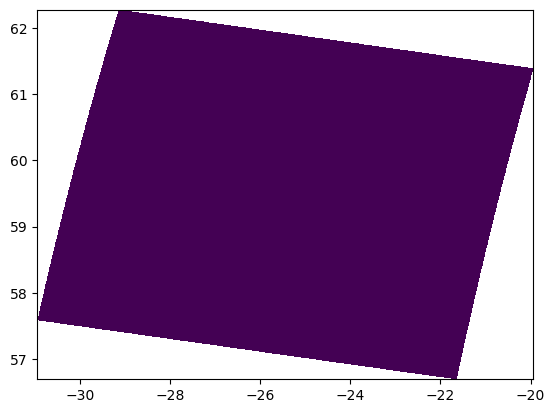

In [9]:
c1=plt.pcolormesh(lon_rho,lat_rho,np.sqrt(ur[9,0,:,:]**2+vr[9,0,:,:]**2))

In [105]:
del ds

In [106]:
ur[9,0,:,:].values

array([[-2.5, -2.5, -2.5, ..., -2.5, -2.5, -2.5],
       [-2.5, -2.5, -2.5, ..., -2.5, -2.5, -2.5],
       [-2.5, -2.5, -2.5, ..., -2.5, -2.5, -2.5],
       ...,
       [-2.5, -2.5, -2.5, ..., -2.5, -2.5, -2.5],
       [-2.5, -2.5, -2.5, ..., -2.5, -2.5, -2.5],
       [-2.5, -2.5, -2.5, ..., -2.5, -2.5, -2.5]])

# Parcels

In [87]:
wavename=f'{wave_dir}wavecase_modified.nc'

In [88]:
wave_dir

'/meddy/simingzhang/Data/Parcels_data/'

In [89]:
wavename
filenames = {"U": wavename, "V": wavename}
filenames

{'U': '/meddy/simingzhang/Data/Parcels_data/wavecase_modified.nc',
 'V': '/meddy/simingzhang/Data/Parcels_data/wavecase_modified.nc'}

In [90]:
variables = {
    "U": "u_rho",
    "V": "v_rho",
}
dimensions = {
    "U": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
    "V": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
}
fieldset = parcels.FieldSet.from_netcdf(filenames, variables, dimensions)
# ,allow_time_extrapolation=True


In [91]:
fieldset

<FieldSet>
    fields:
        <Field>
            name            : 'U'
            grid            : CurvilinearZGrid(lon=array([[-30.93, -30.89, -30.86, ..., -21.72, -21.69, -21.65],
               [-30.92, -30.89, -30.85, ..., -21.71, -21.68, -21.65],
               [-30.91, -30.88, -30.85, ..., -21.71, -21.68, -21.64],
               ...,
               [-29.14, -29.11, -29.08, ..., -20.03, -20.00, -19.97],
               [-29.13, -29.10, -29.07, ..., -20.02, -19.99, -19.96],
               [-29.13, -29.09, -29.06, ..., -20.02, -19.99, -19.95]], dtype=float32), lat=array([[ 57.60,  57.59,  57.59, ...,  56.71,  56.71,  56.71],
               [ 57.61,  57.61,  57.61, ...,  56.73,  56.73,  56.72],
               [ 57.63,  57.63,  57.62, ...,  56.75,  56.74,  56.74],
               ...,
               [ 62.24,  62.23,  62.23, ...,  61.36,  61.36,  61.35],
               [ 62.25,  62.25,  62.25, ...,  61.37,  61.37,  61.37],
               [ 62.27,  62.26,  62.26, ...,  61.39,  61.39, 

In [92]:
fieldset
# fieldset.U.grid.time *= 3600
# fieldset.V.grid.time *= 3600

<FieldSet>
    fields:
        <Field>
            name            : 'U'
            grid            : CurvilinearZGrid(lon=array([[-30.93, -30.89, -30.86, ..., -21.72, -21.69, -21.65],
               [-30.92, -30.89, -30.85, ..., -21.71, -21.68, -21.65],
               [-30.91, -30.88, -30.85, ..., -21.71, -21.68, -21.64],
               ...,
               [-29.14, -29.11, -29.08, ..., -20.03, -20.00, -19.97],
               [-29.13, -29.10, -29.07, ..., -20.02, -19.99, -19.96],
               [-29.13, -29.09, -29.06, ..., -20.02, -19.99, -19.95]], dtype=float32), lat=array([[ 57.60,  57.59,  57.59, ...,  56.71,  56.71,  56.71],
               [ 57.61,  57.61,  57.61, ...,  56.73,  56.73,  56.72],
               [ 57.63,  57.63,  57.62, ...,  56.75,  56.74,  56.74],
               ...,
               [ 62.24,  62.23,  62.23, ...,  61.36,  61.36,  61.35],
               [ 62.25,  62.25,  62.25, ...,  61.37,  61.37,  61.37],
               [ 62.27,  62.26,  62.26, ...,  61.39,  61.39, 

In [30]:
fieldset.U.grid.time


array([    0.,  3600.,  7200., 10800., 14400., 18000., 21600., 25200.,
       28800., 32400.])

In [31]:
fieldset.U.grid.lon,fieldset.U.grid.lat

(array([[-30.925957, -30.893158, -30.860361, ..., -21.718876, -21.686825,
         -21.654776],
        [-30.920086, -30.88729 , -30.854492, ..., -21.713299, -21.681248,
         -21.6492  ],
        [-30.914213, -30.881416, -30.848621, ..., -21.707718, -21.675669,
         -21.643621],
        ...,
        [-29.140213, -29.10769 , -29.07517 , ..., -20.0301  , -19.998451,
         -19.966805],
        [-29.133482, -29.10096 , -29.06844 , ..., -20.023764, -19.992115,
         -19.960472],
        [-29.126745, -29.094225, -29.061707, ..., -20.017424, -19.985779,
         -19.954136]], dtype=float32),
 array([[57.59519 , 57.59204 , 57.588898, ..., 56.712093, 56.70903 ,
         56.70597 ],
        [57.61276 , 57.609615, 57.60647 , ..., 56.72968 , 56.72662 ,
         56.72356 ],
        [57.630325, 57.62718 , 57.624035, ..., 56.747257, 56.744198,
         56.74114 ],
        ...,
        [62.237324, 62.234188, 62.231056, ..., 61.35916 , 61.356125,
         61.35309 ],
        [62.252472, 6

In [32]:
lonp=lon_rho.values
latp=lat_rho.values

step=1
centerpoint=144
# npart=2500
npart=1*1
if (np.sqrt(npart) / 2) % 1 == 0:
    left1=int(np.sqrt(npart)/2)
    right1=int(np.sqrt(npart)/2)
    # print(1)
else:
    left1=int((np.sqrt(npart)+1)/2)
    right1=int((np.sqrt(npart)+1)/2)-1
    # print(2)
II=[centerpoint-left1,centerpoint+right1]
JJ=[centerpoint-left1,centerpoint+right1]
lonp1=lonp[JJ[0]:JJ[1]:step,II[0]:II[1]:step].ravel()
latp1=latp[JJ[0]:JJ[1]:step,II[0]:II[1]:step].ravel()
during=89.5 # days
total_seconds = during * 86400 
outputwavename=f'{wave_dir}testones.zarr'

In [33]:
lonp1.shape

(1,)

In [34]:
def DeleteParticle(particle, fieldset, time):
    if (particle.lon < -30.92595646869225+1.5) or (particle.lon > -19.9541352315797-1.5) or \
       (particle.lat < 56.70597152564239+0.5) or (particle.lat > 62.267609501148414-0.5):
        particle.delete()
        
def SampleT(particle, fieldset, time):
    particle.ue = fieldset.U[time, particle.depth, particle.lat, particle.lon]
    particle.ve = fieldset.V[time, particle.depth, particle.lat, particle.lon]

def CheckOutOfBounds(particle, fieldset, time):
    if particle.state == StatusCode.ErrorOutOfBounds:
        particle.delete()
def CheckError(particle, fieldset, time):
    if particle.state >= 50:  # This captures all Errors
        particle.delete()

SampleParticle = parcels.JITParticle.add_variables(
    [
        parcels.Variable("U", dtype=np.float32, initial=np.nan),
        parcels.Variable("V", dtype=np.float32, initial=np.nan),
    ]
)


def SampleVel_correct(particle, fieldset, time):
    # attention: samples particle velocity in units of the mesh (deg/s or m/s)
    particle.U, particle.V = fieldset.UV[
        time, particle.depth, particle.lat, particle.lon, particle
    ]
    # print(particle.U)



In [35]:

####################################################################################

pset = parcels.ParticleSet.from_list(
    fieldset=fieldset,
    pclass=parcels.JITParticle.add_variables(
    [
        parcels.Variable("U", dtype=np.float32, initial=np.nan),
        parcels.Variable("V", dtype=np.float32, initial=np.nan),
    ]
),
    lon=lonp1,
    lat=latp1,
    # size=100,                # 粒子总数
    # depth=-2*np.ones(lonp1.shape)                  # 释放深度
)

######################################################################################
# pset = parcels.ParticleSet.from_list(
#     fieldset=fieldset,
#     pclass=parcels.JITParticle.add_variable("ue").add_variable("ve"),
#     lon=lonp1,
#     lat=latp1,
#     # size=100,                # 粒子总数
#     depth=-2*np.ones(lonp1.shape)                  # 释放深度
# )
#########################################################################################
# SampleParticleOnce = parcels.JITParticle.add_variable(
#     "U", initial=0, to_write="once"
# )

# pset = parcels.ParticleSet(
#     fieldset=fieldset, pclass=SampleParticleOnce, lon=lonp1, lat=latp1
# )


output_file = pset.ParticleFile(
    name=outputwavename, outputdt=timedelta(hours=1)
)

pset.execute(
    [SampleVel_correct,parcels.AdvectionRK4],  # simply combine the Kernels in a list
    runtime=timedelta(hours=8),
    dt=timedelta(seconds=600),
    output_file=output_file,
)

INFO: Output files are stored in /meddy/simingzhang/Data/Parcels_data/testones.zarr.
100%|████████████████████████████████████████████████████████████| 28800.0/28800.0 [00:07<00:00, 4008.64it/s]


In [36]:
fieldset.U.grid.time

array([25200., 28800.])

In [37]:
fieldset.UV

<VectorField>
    name: 'UV'
    U: <parcels.field.Field object at 0x7fa79b3abda0>
    V: <parcels.field.Field object at 0x7fa74ab5ed80>
    W: None

In [38]:
fieldset.U.gridindexingtype

'nemo'

In [39]:
# [min(lon_rho.values),max(lon_rho.values)]

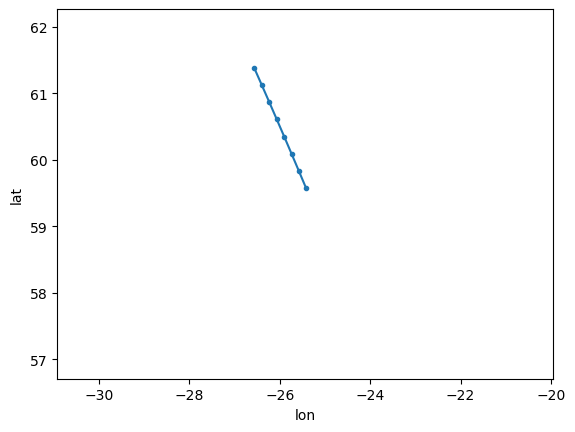

In [40]:
ds = xr.open_zarr(outputwavename)

plt.plot(ds.lon.T, ds.lat.T, ".-")
plt.xlabel("lon")
plt.ylabel("lat")
plt.xlim([np.min(lon_rho.values),np.max(lon_rho.values)])
plt.ylim([np.min(lat_rho.values),np.max(lat_rho.values)])
plt.show()

In [41]:
# del ds1
ds1=xr.open_dataset(wavename)

In [42]:
ds['U'].values*1852*60*np.cos(ds['lat'].values * np.pi / 180),ds['V'].values*1852*60

(array([[-2.4999995, -2.4999998, -2.4999998, -2.4999998, -2.4999998,
         -2.5      , -2.4999998, -2.5      ]], dtype=float32),
 array([[7.9999995, 7.9999995, 7.9999995, 7.9999995, 7.9999995, 7.9999995,
         7.9999995, 7.9999995]], dtype=float32))

In [43]:
ue,ve=transunit_spher2flat(ds['U'].values[0,:],ds['V'].values[0,:],ds['lat'].values[0,:])
ue

array([-2.4999995, -2.4999998, -2.4999998, -2.4999998, -2.4999998,
       -2.5      , -2.4999998, -2.5      ], dtype=float32)

In [44]:
i_indices, j_indices, distances_km=find_nearest_grid_index(lon_rho.values, lat_rho.values, ds['lon'].values[0,:], ds['lat'].values[0,:])
utrue=np.zeros((len(i_indices)))
for tin in range(len(i_indices)):
    utrue[tin]=np.squeeze(ds1['u_rho'].values)[tin,i_indices[tin],j_indices[tin]]

(-2.6, -2.4)

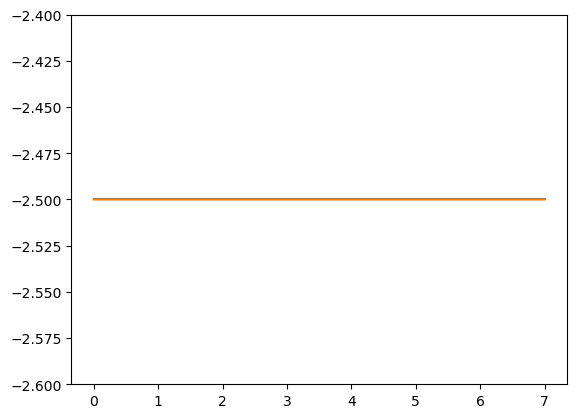

In [47]:
plt.plot(utrue)
plt.plot(np.arange(8),ue)
plt.ylim([-2.6,-2.4])

In [93]:
ds

<xarray.Dataset> Size: 24MB
Dimensions:     (depth: 1, time: 10, eta_rho: 287, xi_u: 286, eta_v: 286,
                 xi_rho: 287)
Coordinates:
  * depth       (depth) float32 4B -2.0
    lon_rho     (eta_rho, xi_rho) float64 659kB -30.93 -30.89 ... -19.99 -19.95
    lat_rho     (eta_rho, xi_rho) float64 659kB 57.6 57.59 57.59 ... 61.39 61.38
Dimensions without coordinates: time, eta_rho, xi_u, eta_v, xi_rho
Data variables:
    ocean_time  (time) float32 40B ...
    u           (time, depth, eta_rho, xi_u) float32 3MB ...
    v           (time, depth, eta_v, xi_rho) float32 3MB ...
    w           (time, depth, eta_rho, xi_rho) float32 3MB ...
    u_rho       (time, depth, eta_rho, xi_rho) float64 7MB ...
    v_rho       (time, depth, eta_rho, xi_rho) float64 7MB ...
Attributes:
    history:                   Thu Aug 28 13:18:24 2025: ncea -d time,1,10 te...
    nco_openmp_thread_number:  1
    NCO:                       netCDF Operators version 5.2.6 (Homepage = htt...

In [145]:
ue

array([-2.4999995, -2.4999998, -2.4999998, -2.4999998, -2.4999998,
       -2.5      , -2.4999998, -2.5      ], dtype=float32)

# idealized tide flow

In [94]:
time_indices = np.arange(120)

# 定义周期性信号的参数
periods = [24, 24, 24]  # 周期
amplitudes = [0.3, 0.4, 0.3]  # 振幅

# 计算时间上的周期性信号
time_signal = np.zeros(120)
for period, amplitude in zip(periods, amplitudes):
    angular_frequency = 2 * np.pi / period
    time_signal += amplitude * np.sin(angular_frequency * time_indices)



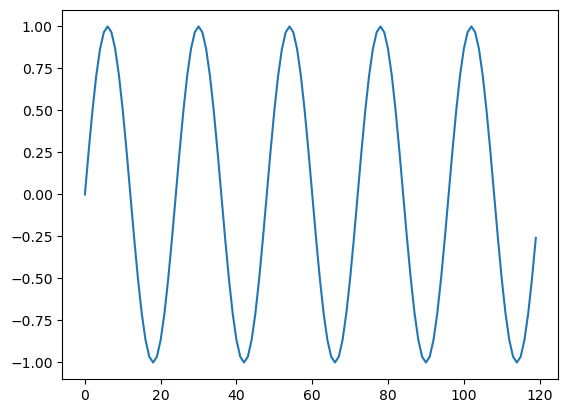

In [95]:
# time_signal.shape
plt.plot(time_signal)
plt.show()

In [96]:
time_signal

array([ 0.00000000e+00,  2.58819045e-01,  5.00000000e-01,  7.07106781e-01,
        8.66025404e-01,  9.65925826e-01,  1.00000000e+00,  9.65925826e-01,
        8.66025404e-01,  7.07106781e-01,  5.00000000e-01,  2.58819045e-01,
        1.22464680e-16, -2.58819045e-01, -5.00000000e-01, -7.07106781e-01,
       -8.66025404e-01, -9.65925826e-01, -1.00000000e+00, -9.65925826e-01,
       -8.66025404e-01, -7.07106781e-01, -5.00000000e-01, -2.58819045e-01,
       -2.44929360e-16,  2.58819045e-01,  5.00000000e-01,  7.07106781e-01,
        8.66025404e-01,  9.65925826e-01,  1.00000000e+00,  9.65925826e-01,
        8.66025404e-01,  7.07106781e-01,  5.00000000e-01,  2.58819045e-01,
        3.67394040e-16, -2.58819045e-01, -5.00000000e-01, -7.07106781e-01,
       -8.66025404e-01, -9.65925826e-01, -1.00000000e+00, -9.65925826e-01,
       -8.66025404e-01, -7.07106781e-01, -5.00000000e-01, -2.58819045e-01,
       -4.89858720e-16,  2.58819045e-01,  5.00000000e-01,  7.07106781e-01,
        8.66025404e-01,  

In [97]:
data_expanded = time_signal[:, np.newaxis, np.newaxis, np.newaxis]
ones_287x287 = np.ones((1, 1, 287, 287))
ut = data_expanded * ones_287x287
vt = data_expanded * ones_287x287

In [98]:
nj=50
ni=50
xf,spec=freqspec(ut[:,0,nj,ni],vt[:,0,nj,ni],fs=1,window=True)
f_freq=4*np.pi*np.sin(np.pi*60/180)*366.25/(24*3600*365.25)*3600/2/np.pi


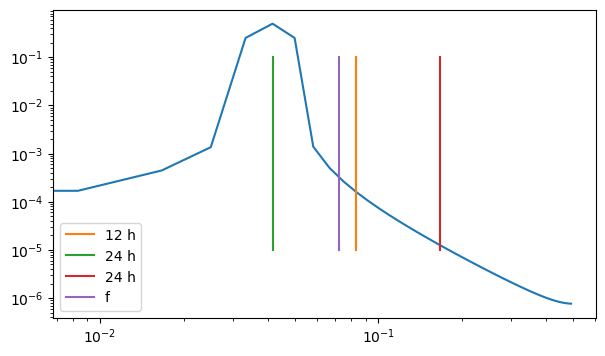

In [99]:
# 绘制频谱
plt.figure(figsize=(7, 4))
plt.loglog(xf, spec)  # 只显示正频率部分
plt.plot([1/12,1/12],[1e-5,1e-1],label='12 h')
plt.plot([1/24,1/24],[1e-5,1e-1],label='24 h')
plt.plot([1/6,1/6],[1e-5,1e-1],label='24 h')

plt.plot([f_freq,f_freq],[1e-5,1e-1],label='f')
plt.legend(loc=3)

In [100]:
ds = xr.open_dataset(f'{wave_dir}testtide.nc')
ds

<xarray.Dataset> Size: 278MB
Dimensions:     (depth: 1, time: 120, eta_rho: 287, xi_u: 286, eta_v: 286,
                 xi_rho: 287)
Coordinates:
  * depth       (depth) float32 4B -2.0
    lon_rho     (eta_rho, xi_rho) float64 659kB ...
    lat_rho     (eta_rho, xi_rho) float64 659kB ...
Dimensions without coordinates: time, eta_rho, xi_u, eta_v, xi_rho
Data variables:
    ocean_time  (time) float32 480B ...
    u           (time, depth, eta_rho, xi_u) float32 39MB ...
    v           (time, depth, eta_v, xi_rho) float32 39MB ...
    w           (time, depth, eta_rho, xi_rho) float32 40MB ...
    u_rho       (time, depth, eta_rho, xi_rho) float64 79MB ...
    v_rho       (time, depth, eta_rho, xi_rho) float64 79MB ...
Attributes:
    history:                   Fri Aug 29 06:13:24 2025: ncea -d time,1,120 w...
    nco_openmp_thread_number:  1
    NCO:                       netCDF Operators version 5.2.6 (Homepage = htt...

In [101]:
u_rho = np.zeros(ds['w'].shape)
u_rho[:,0,:,:]=u2rho_3d(np.squeeze(ds['u'].values))
# u_rho[np.abs(u_rho)<1e-3]=np.nan
ds["u_rho"] = (("time", "depth", "eta_rho", "xi_rho"), ut)
v_rho = np.zeros(ds['w'].shape)
v_rho[:,0,:,:]=v2rho_3d(np.squeeze(ds['v'].values))
# v_rho[np.abs(v_rho)<1e-3]=np.nan
ds["v_rho"] = (("time", "depth", "eta_rho", "xi_rho"), vt)

ds.to_netcdf(f'{wave_dir}testtide120.nc')


In [102]:
ut[:,0,10,60],vt[:,0,10,60]

(array([ 0.00000000e+00,  2.58819045e-01,  5.00000000e-01,  7.07106781e-01,
         8.66025404e-01,  9.65925826e-01,  1.00000000e+00,  9.65925826e-01,
         8.66025404e-01,  7.07106781e-01,  5.00000000e-01,  2.58819045e-01,
         1.22464680e-16, -2.58819045e-01, -5.00000000e-01, -7.07106781e-01,
        -8.66025404e-01, -9.65925826e-01, -1.00000000e+00, -9.65925826e-01,
        -8.66025404e-01, -7.07106781e-01, -5.00000000e-01, -2.58819045e-01,
        -2.44929360e-16,  2.58819045e-01,  5.00000000e-01,  7.07106781e-01,
         8.66025404e-01,  9.65925826e-01,  1.00000000e+00,  9.65925826e-01,
         8.66025404e-01,  7.07106781e-01,  5.00000000e-01,  2.58819045e-01,
         3.67394040e-16, -2.58819045e-01, -5.00000000e-01, -7.07106781e-01,
        -8.66025404e-01, -9.65925826e-01, -1.00000000e+00, -9.65925826e-01,
        -8.66025404e-01, -7.07106781e-01, -5.00000000e-01, -2.58819045e-01,
        -4.89858720e-16,  2.58819045e-01,  5.00000000e-01,  7.07106781e-01,
         8.6

# Parcels

In [143]:
wavename=f'{wave_dir}testtide120.nc'
# wavename=f'{wave_dir}nowavecase_modified_cg.nc'

In [144]:
filenames

{'U': '/meddy/simingzhang/Data/Parcels_data/nowavecase_modified_cg.nc',
 'V': '/meddy/simingzhang/Data/Parcels_data/nowavecase_modified_cg.nc'}

In [145]:
wavename
filenames = {"U": wavename, "V": wavename}
filenames
variables = {
    "U": "u_rho",
    "V": "v_rho",
}
dimensions = {
    "U": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
    "V": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
}
fieldset = parcels.FieldSet.from_netcdf(filenames, variables, dimensions)
# ,allow_time_extrapolation=True

In [146]:
fieldset

<FieldSet>
    fields:
        <Field>
            name            : 'U'
            grid            : CurvilinearZGrid(lon=array([[-30.93, -30.89, -30.86, ..., -21.72, -21.69, -21.65],
               [-30.92, -30.89, -30.85, ..., -21.71, -21.68, -21.65],
               [-30.91, -30.88, -30.85, ..., -21.71, -21.68, -21.64],
               ...,
               [-29.14, -29.11, -29.08, ..., -20.03, -20.00, -19.97],
               [-29.13, -29.10, -29.07, ..., -20.02, -19.99, -19.96],
               [-29.13, -29.09, -29.06, ..., -20.02, -19.99, -19.95]], dtype=float32), lat=array([[ 57.60,  57.59,  57.59, ...,  56.71,  56.71,  56.71],
               [ 57.61,  57.61,  57.61, ...,  56.73,  56.73,  56.72],
               [ 57.63,  57.63,  57.62, ...,  56.75,  56.74,  56.74],
               ...,
               [ 62.24,  62.23,  62.23, ...,  61.36,  61.36,  61.35],
               [ 62.25,  62.25,  62.25, ...,  61.37,  61.37,  61.37],
               [ 62.27,  62.26,  62.26, ...,  61.39,  61.39, 

In [147]:
fieldset
# fieldset.U.grid.time *= 3600
# fieldset.V.grid.time *= 3600

<FieldSet>
    fields:
        <Field>
            name            : 'U'
            grid            : CurvilinearZGrid(lon=array([[-30.93, -30.89, -30.86, ..., -21.72, -21.69, -21.65],
               [-30.92, -30.89, -30.85, ..., -21.71, -21.68, -21.65],
               [-30.91, -30.88, -30.85, ..., -21.71, -21.68, -21.64],
               ...,
               [-29.14, -29.11, -29.08, ..., -20.03, -20.00, -19.97],
               [-29.13, -29.10, -29.07, ..., -20.02, -19.99, -19.96],
               [-29.13, -29.09, -29.06, ..., -20.02, -19.99, -19.95]], dtype=float32), lat=array([[ 57.60,  57.59,  57.59, ...,  56.71,  56.71,  56.71],
               [ 57.61,  57.61,  57.61, ...,  56.73,  56.73,  56.72],
               [ 57.63,  57.63,  57.62, ...,  56.75,  56.74,  56.74],
               ...,
               [ 62.24,  62.23,  62.23, ...,  61.36,  61.36,  61.35],
               [ 62.25,  62.25,  62.25, ...,  61.37,  61.37,  61.37],
               [ 62.27,  62.26,  62.26, ...,  61.39,  61.39, 

In [148]:
lonp=lon_rho.values
latp=lat_rho.values

step=1
centerpoint=144
# npart=2500
npart=2*2
if (np.sqrt(npart) / 2) % 1 == 0:
    left1=int(np.sqrt(npart)/2)
    right1=int(np.sqrt(npart)/2)
    # print(1)
else:
    left1=int((np.sqrt(npart)+1)/2)
    right1=int((np.sqrt(npart)+1)/2)-1
    # print(2)
II=[centerpoint-left1,centerpoint+right1]
JJ=[centerpoint-left1,centerpoint+right1]
lonp1=lonp[JJ[0]:JJ[1]:step,II[0]:II[1]:step].ravel()
latp1=latp[JJ[0]:JJ[1]:step,II[0]:II[1]:step].ravel()
during=89.5 # days
total_seconds = during * 86400 
outputwavename=f'{wave_dir}testones.zarr'

In [149]:
lonp1,latp1

(array([-25.41539024, -25.38313859, -25.40925939, -25.37700894]),
 array([59.57201626, 59.56891215, 59.58834673, 59.58524267]))

In [150]:
def DeleteParticle(particle, fieldset, time):
    if (particle.lon < -30.92595646869225+1.5) or (particle.lon > -19.9541352315797-1.5) or \
       (particle.lat < 56.70597152564239+0.5) or (particle.lat > 62.267609501148414-0.5):
        particle.delete()
        
def SampleT(particle, fieldset, time):
    particle.ue = fieldset.U[time, particle.depth, particle.lat, particle.lon]
    particle.ve = fieldset.V[time, particle.depth, particle.lat, particle.lon]

def CheckOutOfBounds(particle, fieldset, time):
    if particle.state == StatusCode.ErrorOutOfBounds:
        particle.delete()
def CheckError(particle, fieldset, time):
    if particle.state >= 50:  # This captures all Errors
        particle.delete()

SampleParticle = parcels.JITParticle.add_variables(
    [
        parcels.Variable("U", dtype=np.float32, initial=np.nan),
        parcels.Variable("V", dtype=np.float32, initial=np.nan),
    ]
)


def SampleVel_correct(particle, fieldset, time):
    # attention: samples particle velocity in units of the mesh (deg/s or m/s)
    particle.U, particle.V = fieldset.UV[
        time, particle.depth, particle.lat, particle.lon, particle
    ]



In [151]:
# pset = parcels.ParticleSet.from_list(
#     fieldset=fieldset,
#     pclass=parcels.JITParticle.add_variables(
#     [
#         parcels.Variable("U", dtype=np.float32, initial=np.nan),
#         parcels.Variable("V", dtype=np.float32, initial=np.nan),
#     ]
# ),
#     lon=lonp1,
#     lat=latp1,
#     # size=100,                # 粒子总数
#     # depth=-2*np.ones(lonp1.shape)                  # 释放深度
# )

pset = parcels.ParticleSet.from_list(
    fieldset=fieldset,
    pclass=parcels.JITParticle.add_variable("ue").add_variable("ve"),
    lon=lonp1,
    lat=latp1,
    # size=100,                # 粒子总数
    depth=-2*np.ones(lonp1.shape)                  # 释放深度
)

# SampleParticleOnce = parcels.JITParticle.add_variable(
#     "U", initial=0, to_write="once"
# )

# pset = parcels.ParticleSet(
#     fieldset=fieldset, pclass=SampleParticleOnce, lon=lonp1, lat=latp1
# )


output_file = pset.ParticleFile(
    name=outputwavename, outputdt=timedelta(hours=1)
)

pset.execute(
    [SampleT,parcels.AdvectionRK4],  # simply combine the Kernels in a list
    runtime=timedelta(hours=120),
    dt=timedelta(seconds=600),
    output_file=output_file,
)

/home/simingzhang/anaconda3/lib/python3.12/site-packages/parcels/field.py:1180: RuntimeWarning: Sampling of velocities should normally be done using fieldset.UV or fieldset.UVW object; tread carefully
  self._check_velocitysampling()


INFO: Output files are stored in /meddy/simingzhang/Data/Parcels_data/testones.zarr.
 99%|█████████████████████████████████████████████████████████▌| 428400.0/432000.0 [01:35<00:00, 4885.26it/s]

TimeExtrapolationError: U sampled outside time domain at time 694756800.0. Try setting allow_time_extrapolation to True.

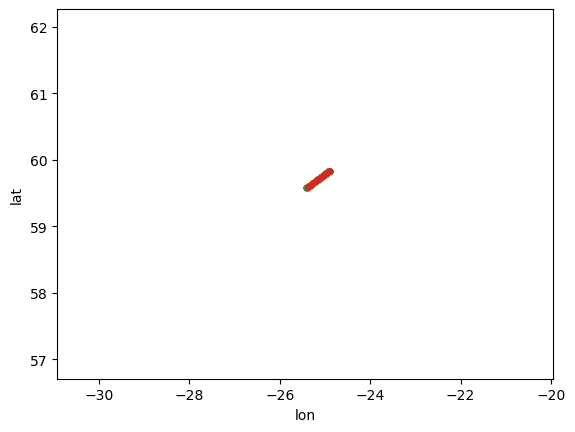

In [159]:

ds = xr.open_zarr(outputwavename)

plt.plot(ds.lon.T, ds.lat.T, ".-")
plt.xlabel("lon")
plt.ylabel("lat")
plt.xlim([np.min(lon_rho.values),np.max(lon_rho.values)])
plt.ylim([np.min(lat_rho.values),np.max(lat_rho.values)])
plt.show()

In [160]:
ds['ue'].values.shape
ds['lon'].values
lon_rho.shape

(287, 287)

In [161]:
# ds['lon'].values[0].shape
lon_rho

<xarray.DataArray 'lon_rho' (eta_rho: 287, xi_rho: 287)> Size: 659kB
array([[-30.925956, -30.893158, -30.860362, ..., -21.718877, -21.686825,
        -21.654775],
       [-30.920086, -30.887288, -30.854493, ..., -21.713299, -21.681248,
        -21.6492  ],
       [-30.914213, -30.881416, -30.848622, ..., -21.707719, -21.675669,
        -21.643622],
       ...,
       [-29.140214, -29.10769 , -29.07517 , ..., -20.0301  , -19.998451,
        -19.966805],
       [-29.133482, -29.100959, -29.06844 , ..., -20.023763, -19.992116,
        -19.960471],
       [-29.126746, -29.094225, -29.061707, ..., -20.017424, -19.985778,
        -19.954135]])
Dimensions without coordinates: eta_rho, xi_rho
Attributes:
    long_name:  longitude of RHO-points
    units:      degree_east

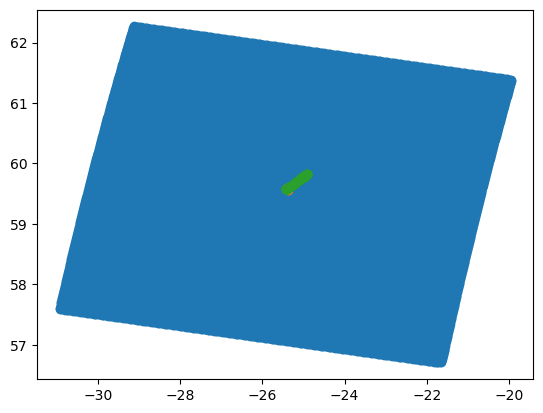

In [162]:
plt.scatter(lon_rho.values.ravel(),lat_rho.values.ravel())
plt.scatter(lonp1,latp1)
plt.scatter(ds['lon'].values[0,:], ds['lat'].values[0,:])

In [163]:
# np.squeeze(ds1['u_rho'].values)[1,i_indices,j_indices]
# np.squeeze(ds1['v_rho'].values)[1,i_indices,j_indices]
ds1=xr.open_dataset(f'{wave_dir}testtide120.nc')
i_indices, j_indices, distances_km=find_nearest_grid_index(lon_rho.values, lat_rho.values, ds['lon'].values[0,:], ds['lat'].values[0,:])
utrue=np.zeros((len(i_indices)))
for tin in range(len(i_indices)):
    utrue[tin]=np.squeeze(ds1['u_rho'].values)[tin,i_indices[tin],j_indices[tin]]
ue,ve=transunit_spher2flat(ds['ue'].values,ds['ve'].values,ds['lat'].values)


In [164]:
ds['ue'].values=ue

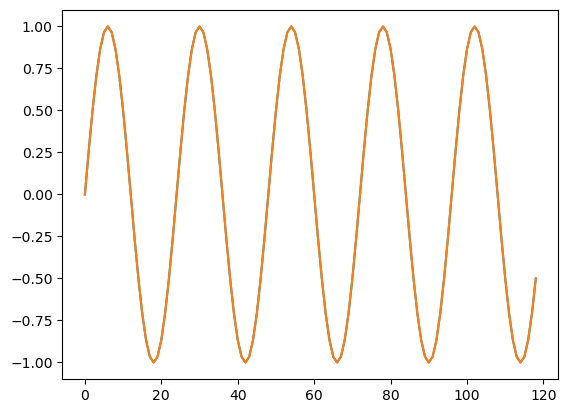

In [165]:
plt.plot(ds['ue'].values[1,:])
plt.plot(ue[1,:])

In [166]:
ds['ue'].values.shape

(4, 119)

In [167]:
utrue

array([ 0.00000000e+00,  2.58819045e-01,  5.00000000e-01,  7.07106781e-01,
        8.66025404e-01,  9.65925826e-01,  1.00000000e+00,  9.65925826e-01,
        8.66025404e-01,  7.07106781e-01,  5.00000000e-01,  2.58819045e-01,
        1.22464680e-16, -2.58819045e-01, -5.00000000e-01, -7.07106781e-01,
       -8.66025404e-01, -9.65925826e-01, -1.00000000e+00, -9.65925826e-01,
       -8.66025404e-01, -7.07106781e-01, -5.00000000e-01, -2.58819045e-01,
       -2.44929360e-16,  2.58819045e-01,  5.00000000e-01,  7.07106781e-01,
        8.66025404e-01,  9.65925826e-01,  1.00000000e+00,  9.65925826e-01,
        8.66025404e-01,  7.07106781e-01,  5.00000000e-01,  2.58819045e-01,
        3.67394040e-16, -2.58819045e-01, -5.00000000e-01, -7.07106781e-01,
       -8.66025404e-01, -9.65925826e-01, -1.00000000e+00, -9.65925826e-01,
       -8.66025404e-01, -7.07106781e-01, -5.00000000e-01, -2.58819045e-01,
       -4.89858720e-16,  2.58819045e-01,  5.00000000e-01,  7.07106781e-01,
        8.66025404e-01,  

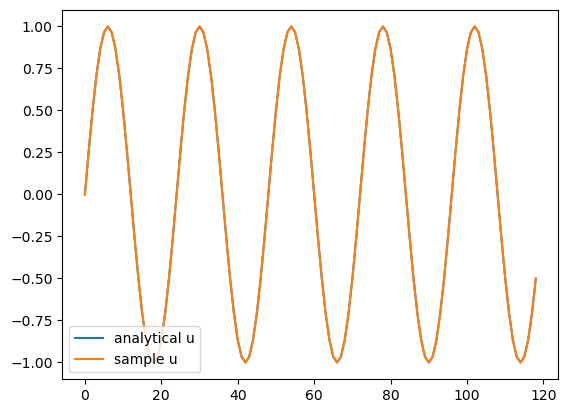

In [169]:
plt.plot(utrue,label='analytical u')
plt.plot(ue[2,:],label='sample u')
plt.legend(loc=3)


# Check spec

In [86]:
nj=50
ni=50
xf,spec=freqspec(ut[:,0,nj,ni],vt[:,0,nj,ni],fs=1,window=True)
ue,ve=transunit_spher2flat(ds['ue'].values[0,:],ds['ve'].values[0,:],ds['lat'].values[0,:])
xfe,spece=freqspec(ue,ve,fs=1.0/0.2,window=True)

f_freq=4*np.pi*np.sin(np.pi*60/180)*366.25/(24*3600*365.25)*3600/2/np.pi

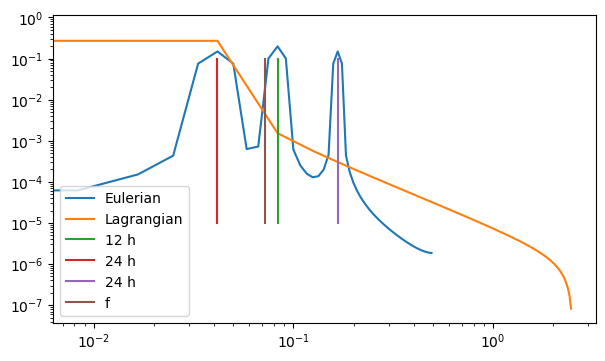

In [30]:
plt.figure(figsize=(7, 4))
plt.loglog(xf, spec,label='Eulerian')  # 只显示正频率部分
plt.loglog(xfe, spece,label='Lagrangian')
plt.plot([1/12,1/12],[1e-5,1e-1],label='12 h')
plt.plot([1/24,1/24],[1e-5,1e-1],label='24 h')
plt.plot([1/6,1/6],[1e-5,1e-1],label='24 h')

plt.plot([f_freq,f_freq],[1e-5,1e-1],label='f')
plt.legend(loc=3)

# new tide

In [97]:
new_dir='/meddy/simingzhang/Data/Parcels_data/TEST/'

In [98]:
# filenames = {
#     "U": f"{new_dir}testtide_time_*.nc",
#     "V": f"{new_dir}testtide_time_*.nc",
# }

filenames = {
    "U": f"{new_dir}testtide120.nc",
    "V": f"{new_dir}testtide120.nc",
}

In [99]:
filenames

{'U': '/meddy/simingzhang/Data/Parcels_data/TEST/testtide120.nc',
 'V': '/meddy/simingzhang/Data/Parcels_data/TEST/testtide120.nc'}

In [100]:
fieldset

<FieldSet>
    fields:
        <Field>
            name            : 'U'
            grid            : CurvilinearZGrid(lon=array([[-30.93, -30.89, -30.86, ..., -21.72, -21.69, -21.65],
               [-30.92, -30.89, -30.85, ..., -21.71, -21.68, -21.65],
               [-30.91, -30.88, -30.85, ..., -21.71, -21.68, -21.64],
               ...,
               [-29.14, -29.11, -29.08, ..., -20.03, -20.00, -19.97],
               [-29.13, -29.10, -29.07, ..., -20.02, -19.99, -19.96],
               [-29.13, -29.09, -29.06, ..., -20.02, -19.99, -19.95]], dtype=float32), lat=array([[ 57.60,  57.59,  57.59, ...,  56.71,  56.71,  56.71],
               [ 57.61,  57.61,  57.61, ...,  56.73,  56.73,  56.72],
               [ 57.63,  57.63,  57.62, ...,  56.75,  56.74,  56.74],
               ...,
               [ 62.24,  62.23,  62.23, ...,  61.36,  61.36,  61.35],
               [ 62.25,  62.25,  62.25, ...,  61.37,  61.37,  61.37],
               [ 62.27,  62.26,  62.26, ...,  61.39,  61.39, 

In [101]:
variables = {
    "U": "u_rho",
    "V": "v_rho",
}
dimensions = {
    "U": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
    "V": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
}
fieldset = parcels.FieldSet.from_netcdf(filenames, variables, dimensions)

In [102]:
fieldset

<FieldSet>
    fields:
        <Field>
            name            : 'U'
            grid            : CurvilinearZGrid(lon=array([[-30.93, -30.89, -30.86, ..., -21.72, -21.69, -21.65],
               [-30.92, -30.89, -30.85, ..., -21.71, -21.68, -21.65],
               [-30.91, -30.88, -30.85, ..., -21.71, -21.68, -21.64],
               ...,
               [-29.14, -29.11, -29.08, ..., -20.03, -20.00, -19.97],
               [-29.13, -29.10, -29.07, ..., -20.02, -19.99, -19.96],
               [-29.13, -29.09, -29.06, ..., -20.02, -19.99, -19.95]], dtype=float32), lat=array([[ 57.60,  57.59,  57.59, ...,  56.71,  56.71,  56.71],
               [ 57.61,  57.61,  57.61, ...,  56.73,  56.73,  56.72],
               [ 57.63,  57.63,  57.62, ...,  56.75,  56.74,  56.74],
               ...,
               [ 62.24,  62.23,  62.23, ...,  61.36,  61.36,  61.35],
               [ 62.25,  62.25,  62.25, ...,  61.37,  61.37,  61.37],
               [ 62.27,  62.26,  62.26, ...,  61.39,  61.39, 

In [103]:
lonp=lon_rho.values
latp=lat_rho.values

step=1
centerpoint=144
# npart=2500
npart=1*1
if (np.sqrt(npart) / 2) % 1 == 0:
    left1=int(np.sqrt(npart)/2)
    right1=int(np.sqrt(npart)/2)
    # print(1)
else:
    left1=int((np.sqrt(npart)+1)/2)
    right1=int((np.sqrt(npart)+1)/2)-1
    # print(2)
II=[centerpoint-left1,centerpoint+right1]
JJ=[centerpoint-left1,centerpoint+right1]
lonp1=lonp[JJ[0]:JJ[1]:step,II[0]:II[1]:step].ravel()
latp1=latp[JJ[0]:JJ[1]:step,II[0]:II[1]:step].ravel()
during=89.5 # days
total_seconds = during * 86400 
outputwavename=f'{wave_dir}testnew120.zarr'

In [104]:
pset = parcels.ParticleSet.from_list(
    fieldset=fieldset,
    pclass=parcels.JITParticle.add_variable("ue").add_variable("ve"),
    lon=lonp1,
    lat=latp1,
    # size=100,                # 粒子总数
    depth=-2*np.ones(lonp1.shape)                  # 释放深度
)


output_file = pset.ParticleFile(
    name=outputwavename, outputdt=timedelta(hours=1)
)

pset.execute(
    [SampleT,parcels.AdvectionRK4],  # simply combine the Kernels in a list
    runtime=timedelta(hours=120),
    dt=timedelta(seconds=600),
    output_file=output_file,
)

/home/simingzhang/anaconda3/lib/python3.12/site-packages/parcels/field.py:1180: RuntimeWarning: Sampling of velocities should normally be done using fieldset.UV or fieldset.UVW object; tread carefully
  self._check_velocitysampling()


INFO: Output files are stored in /meddy/simingzhang/Data/Parcels_data/testnew120.zarr.

  0%|                                                                           | 0/432000.0 [00:00<?, ?it/s]
  0%|                                                              | 600.0/432000.0 [00:01<19:37, 366.42it/s]
  1%|▌                                                           | 3648.0/432000.0 [00:01<02:49, 2532.04it/s]
  2%|█                                                           | 7200.0/432000.0 [00:02<01:47, 3960.14it/s]
  2%|█▍                                                         | 10800.0/432000.0 [00:03<01:34, 4443.70it/s]
  3%|█▉                                                         | 14400.0/432000.0 [00:04<01:39, 4191.95it/s]
  3%|██                                                         | 15000.0/432000.0 [00:04<02:01, 3427.76it/s]
  4%|██▍                                                        | 17984.0/432000.0 [00:04<01:26, 4811.79it/s]
  5%|██▉                        

TimeExtrapolationError: U sampled outside time domain at time 694756800.0. Try setting allow_time_extrapolation to True.

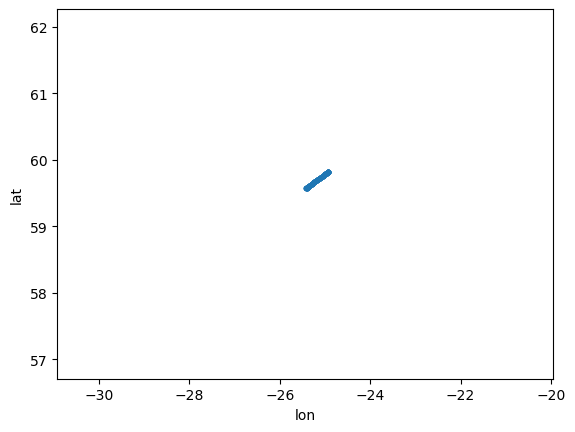

In [105]:
ds = xr.open_zarr(outputwavename)

plt.plot(ds.lon.T, ds.lat.T, ".-")
plt.xlabel("lon")
plt.ylabel("lat")
plt.xlim([np.min(lon_rho.values),np.max(lon_rho.values)])
plt.ylim([np.min(lat_rho.values),np.max(lat_rho.values)])
plt.show()

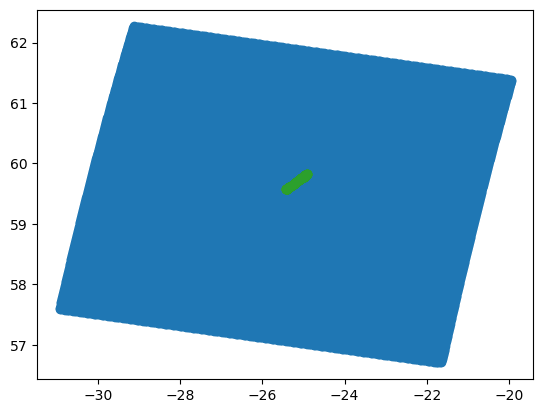

In [106]:
plt.scatter(lon_rho.values.ravel(),lat_rho.values.ravel())
plt.scatter(lonp1,latp1)
plt.scatter(ds['lon'].values[0,:], ds['lat'].values[0,:])

In [107]:
ds1=xr.open_dataset(f'{wave_dir}testtide120.nc')
i_indices, j_indices, distances_km=find_nearest_grid_index(lon_rho.values, lat_rho.values, ds['lon'].values[0,:], ds['lat'].values[0,:])
utrue=np.zeros((len(i_indices)))
for tin in range(len(i_indices)):
    utrue[tin]=np.squeeze(ds1['u_rho'].values)[tin,i_indices[tin],j_indices[tin]]
ue,ve=transunit_spher2flat(ds['ue'].values[0,:],ds['ve'].values[0,:],ds['lat'].values[0,:])


 99%|█████████████████████████████████████████████████████████▌| 428400.0/432000.0 [02:05<00:00, 4657.25it/s]

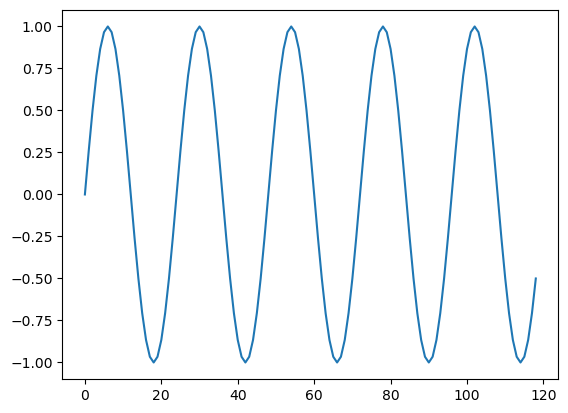

In [108]:
# plt.plot(utrue)
plt.plot(ue)

# check vel direction

In [6]:
ds = xr.open_dataset(f'{wave_dir}test1.nc')

ds['u_rho'].values=np.zeros((2148,1,287,287))
ds['v_rho'].values=np.ones((2148,1,287,287))


In [8]:
ds.to_netcdf(f'{wave_dir}test2.nc')

In [9]:
wavename=f'{wave_dir}test2.nc'

In [10]:
wavename
# filenames = {"U": wavename, "V": wavename,"PI2": wavename,"PI4": wavename,"PI6": wavename,"PI8": wavename,"PI10": wavename,
#             "PI12": wavename,"PI16": wavename,"PI20": wavename,"PI30": wavename,"PI50": wavename,"PI60": wavename,"PI100": wavename}

filenames = {"U": wavename, "V": wavename}


filenames

{'U': '/meddy/simingzhang/Data/Parcels_data/test2.nc',
 'V': '/meddy/simingzhang/Data/Parcels_data/test2.nc'}

In [11]:
variables = {
    "U": "u_rho",
    "V": "v_rho",
}
dimensions = {
    "U": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
    "V": {"lat": "lat_rho", "lon": "lon_rho", "time": "ocean_time", "depth": "depth",},
}

In [12]:
fieldset = parcels.FieldSet.from_netcdf(filenames, variables, dimensions,allow_time_extrapolation=True)


In [14]:
def DeleteParticle(particle, fieldset, time):
    if (particle.lon < -30.92595646869225+1.5) or (particle.lon > -19.9541352315797-1.5) or \
       (particle.lat < 56.70597152564239+0.5) or (particle.lat > 62.267609501148414-0.5):
        particle.delete()
        
# def SampleT(particle, fieldset, time):
#     particle.ue = fieldset.U[time, particle.depth, particle.lat, particle.lon]
#     particle.ve = fieldset.V[time, particle.depth, particle.lat, particle.lon]
#     particle.pi2 = fieldset.PI2[time, particle.depth, particle.lat, particle.lon]
#     particle.pi4 = fieldset.PI4[time, particle.depth, particle.lat, particle.lon]
#     particle.pi6 = fieldset.PI6[time, particle.depth, particle.lat, particle.lon]
#     particle.pi8 = fieldset.PI8[time, particle.depth, particle.lat, particle.lon]
#     particle.pi10 = fieldset.PI10[time, particle.depth, particle.lat, particle.lon]
#     particle.pi12 = fieldset.PI12[time, particle.depth, particle.lat, particle.lon]
#     particle.pi16 = fieldset.PI16[time, particle.depth, particle.lat, particle.lon]
#     particle.pi20 = fieldset.PI20[time, particle.depth, particle.lat, particle.lon]
#     particle.pi30 = fieldset.PI30[time, particle.depth, particle.lat, particle.lon]
#     particle.pi50 = fieldset.PI50[time, particle.depth, particle.lat, particle.lon]
#     particle.pi60 = fieldset.PI60[time, particle.depth, particle.lat, particle.lon]
#     particle.pi100 = fieldset.PI100[time, particle.depth, particle.lat, particle.lon]

def SampleT(particle, fieldset, time):
    particle.ue = fieldset.U[time, particle.depth, particle.lat, particle.lon]
    particle.ve = fieldset.V[time, particle.depth, particle.lat, particle.lon]
    particle.th1 = fieldset.Th1[time, particle.depth, particle.lat, particle.lon]
    particle.th2 = fieldset.Th2[time, particle.depth, particle.lat, particle.lon]
    particle.th3 = fieldset.Th3[time, particle.depth, particle.lat, particle.lon]
    particle.th4 = fieldset.Th4[time, particle.depth, particle.lat, particle.lon]
    particle.th5 = fieldset.Th5[time, particle.depth, particle.lat, particle.lon]
    particle.th6 = fieldset.Th6[time, particle.depth, particle.lat, particle.lon]
    particle.th7 = fieldset.Th7[time, particle.depth, particle.lat, particle.lon]
    particle.th8 = fieldset.Th8[time, particle.depth, particle.lat, particle.lon]
    particle.th9 = fieldset.Th9[time, particle.depth, particle.lat, particle.lon]
    particle.th10 = fieldset.Th10[time, particle.depth, particle.lat, particle.lon]
    particle.th11 = fieldset.Th11[time, particle.depth, particle.lat, particle.lon]
    particle.th12 = fieldset.Th12[time, particle.depth, particle.lat, particle.lon]
    particle.th13 = fieldset.Th13[time, particle.depth, particle.lat, particle.lon]
    particle.th14 = fieldset.Th14[time, particle.depth, particle.lat, particle.lon]
    particle.th15 = fieldset.Th15[time, particle.depth, particle.lat, particle.lon]
    particle.th16 = fieldset.Th16[time, particle.depth, particle.lat, particle.lon]
    particle.th17 = fieldset.Th17[time, particle.depth, particle.lat, particle.lon]
    particle.th18 = fieldset.Th18[time, particle.depth, particle.lat, particle.lon]
    particle.th21 = fieldset.Th21[time, particle.depth, particle.lat, particle.lon]
    particle.th24 = fieldset.Th24[time, particle.depth, particle.lat, particle.lon]
    particle.th27 = fieldset.Th27[time, particle.depth, particle.lat, particle.lon]
    particle.th30 = fieldset.Th30[time, particle.depth, particle.lat, particle.lon]
    particle.th33 = fieldset.Th33[time, particle.depth, particle.lat, particle.lon]
    particle.th36 = fieldset.Th36[time, particle.depth, particle.lat, particle.lon]
    particle.th39 = fieldset.Th39[time, particle.depth, particle.lat, particle.lon]
    particle.th42 = fieldset.Th42[time, particle.depth, particle.lat, particle.lon]
    particle.th45 = fieldset.Th45[time, particle.depth, particle.lat, particle.lon]
    particle.th48 = fieldset.Th48[time, particle.depth, particle.lat, particle.lon]
    particle.th54 = fieldset.Th54[time, particle.depth, particle.lat, particle.lon]
    particle.th60 = fieldset.Th60[time, particle.depth, particle.lat, particle.lon]
    particle.th66 = fieldset.Th66[time, particle.depth, particle.lat, particle.lon]
    particle.th72 = fieldset.Th72[time, particle.depth, particle.lat, particle.lon]
    particle.th78 = fieldset.Th78[time, particle.depth, particle.lat, particle.lon]
    particle.th84 = fieldset.Th84[time, particle.depth, particle.lat, particle.lon]
    particle.th90 = fieldset.Th90[time, particle.depth, particle.lat, particle.lon]
    particle.th96 = fieldset.Th96[time, particle.depth, particle.lat, particle.lon]
    particle.th102 = fieldset.Th102[time, particle.depth, particle.lat, particle.lon]
    particle.th108 = fieldset.Th108[time, particle.depth, particle.lat, particle.lon]
    particle.th114 = fieldset.Th114[time, particle.depth, particle.lat, particle.lon]

def CheckOutOfBounds(particle, fieldset, time):
    if particle.state == StatusCode.ErrorOutOfBounds:
        particle.delete()
def CheckError(particle, fieldset, time):
    if particle.state >= 50:  # This captures all Errors
        particle.delete()

In [15]:
lonp=lon_rho.values
latp=lat_rho.values
# Range=20
# JJ=[Range,287-Range]
# II=[Range,287-Range]
# step=1
# lonp1=lonp[JJ[0]:JJ[1]:step,II[0]:II[1]:step].ravel()
# latp1=latp[JJ[0]:JJ[1]:step,II[0]:II[1]:step].ravel()
step=1
centerpoint=144
# npart=2500
npart=2*2
nrelease=1
repeatdt=6
if (np.sqrt(npart) / 2) % 1 == 0:
    left1=int(np.sqrt(npart)/2)
    right1=int(np.sqrt(npart)/2)
    # print(1)
else:
    left1=int((np.sqrt(npart)+1)/2)
    right1=int((np.sqrt(npart)+1)/2)-1
    # print(2)
II=[centerpoint-left1,centerpoint+right1]
JJ=[centerpoint-left1,centerpoint+right1]
lonp1=lonp[JJ[0]:JJ[1]:step,II[0]:II[1]:step].ravel()
latp1=latp[JJ[0]:JJ[1]:step,II[0]:II[1]:step].ravel()
during=89.5 # days
total_seconds = during * 86400 
# outputwavename=f'{wave_dir}wave_pars_P{latp1.shape[0]}T{during}days.zarr'
lonp2= np.tile(lonp1, int(nrelease))
latp2= np.tile(latp1, int(nrelease))
timep2=np.repeat(np.arange(0, int(nrelease))*timedelta(hours=repeatdt).total_seconds(),npart)
outputwavename=f'{wave_dir}wave_pars_P{int(lonp1.shape[0])}T{during}days.zarr'

In [16]:
# repeatdt = timedelta(hours=6)
pset = parcels.ParticleSet.from_list(
    fieldset=fieldset,
    pclass=parcels.JITParticle,
    lon=lonp1,
    lat=latp1,
    # size=100,                # 粒子总数
    depth=-2*np.ones(lonp1.shape),
    # time=timep2,
    # repeatdt=repeatdt,
    # chunks=(10000, 1),
)


output_file = pset.ParticleFile(
    name=outputwavename, outputdt=timedelta(hours=1)
)

pset.execute(
    [parcels.AdvectionRK4,CheckOutOfBounds],  # simply combine the Kernels in a list
    runtime=timedelta(hours=2148),
    dt=timedelta(seconds=600),
    output_file=output_file,
)

# pset.repeatdt = None


# pset.execute(
#     [SampleT,parcels.AdvectionRK4,CheckOutOfBounds],  # simply combine the Kernels in a list
#     # runtime=timedelta(hours=9),
#     runtime=timedelta(hours=2098),
#     dt=timedelta(seconds=600),
#     output_file=output_file,
# )

INFO: Output files are stored in /meddy/simingzhang/Data/Parcels_data/wave_pars_P4T89.5days.zarr.
  3%|█▎                                         | 244800.0/7732800.0 [00:02<00:51, 144592.36it/s]Correct cell not found for (lat, lon) = (61.909540, -25.409260) after 1000000 iterations
Debug info: old particle indices: (yi, xi) 285 114
            new particle indices: (yi, xi) 285 173
            Mesh 2d shape:  287 287
            Relative particle position:  (eta, xsi) 1.0435306966709075e+00 -4.7422472642300380e-02
Correct cell not found for (lat, lon) = (61.906435, -25.377008) after 1000000 iterations
Debug info: old particle indices: (yi, xi) 285 115
            new particle indices: (yi, xi) 285 172
            Mesh 2d shape:  287 287
            Relative particle position:  (eta, xsi) 1.0441487253414263e+00 -4.4464267758026019e-02
Correct cell not found for (lat, lon) = (61.912101, -25.415390) after 1000000 iterations
Debug info: old particle indices: (yi, xi) 285 114
            n

41

In [18]:
ds = xr.open_zarr(outputwavename)


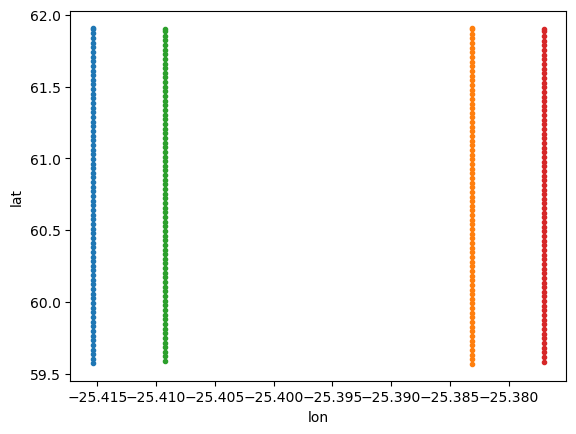

In [19]:
plt.plot(ds.lon.T, ds.lat.T, ".-")
plt.xlabel("lon")
plt.ylabel("lat")
plt.show()